# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

C:\Users\maxva\AppData\Local\Temp\ipykernel_27288\1049158295.py:17: RuntimeWarning: overflow encountered in exp
  return T_lim-(T_lim-T[0])*np.exp(-a*t)


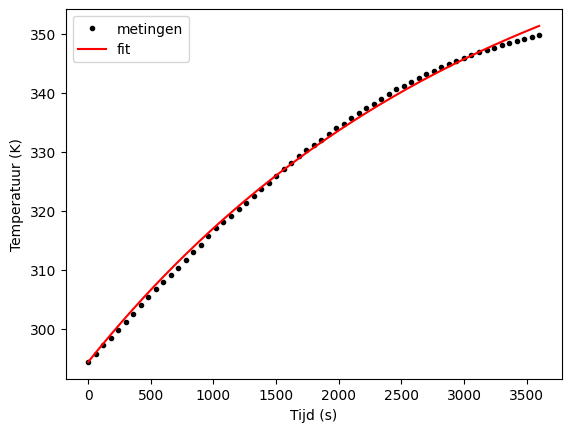

De totale gebruikte energie is: 1.475e+02 kJ


In [69]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data = np.loadtxt("tempmetingen.csv",skiprows = 1, delimiter = ";")

t = data[:,0]*60 #s
T = data[:,1]+273.15 #K

m_maatbeker = 820.8/1e3 #kg
m_maatbeker_en_water_start = 1292.9/1e3 #kg
m_maatbeker_en_water_eind = 1274.9/1e3 #kg

#grafiek vlakt af dus exponentiele benadering naar Tlim

def fit(t, T_lim, a):
    return T_lim-(T_lim-T[0])*np.exp(-a*t)

p0 = [355, 0.1]

popt, pcov = curve_fit(fit, t, T, p0 = p0)

x_fit = np.linspace(np.min(t), np.max(t),1000)
y_fit = fit(x_fit, *popt)

plt.figure()
plt.plot(t,T,"k.", label = "metingen")
plt.plot(x_fit, y_fit, "r-", label = "fit")
plt.xlabel("Tijd (s)")
plt.ylabel("Temperatuur (K)")
plt.legend()
plt.show()

verdampingswarmte_water = 2336 #kJ/kg, dit is bij 70 graden (gemmidelde is 50 graden maar we nemen aan dat het meeste verdampt bij hogere temperaturen)
cwater = 4.19 #kJ/kgK

dT = T[-1]-T[0]

m_water_verdampt = m_maatbeker_en_water_start-m_maatbeker_en_water_eind #kg
m_water_begin = m_maatbeker_en_water_start-m_maatbeker #kg
m_water_eind = m_maatbeker_en_water_eind-m_maatbeker #kg

#Er is aangenomen dat verdampt water niet meetelt bij verwarmt water, er dat alle warmte in het water wordt gestopt
E_verdamping = m_water_verdampt*verdampingswarmte_water #kJ
E_verwarming = m_water_eind*cwater*dT #kJ
E_totaal = E_verdamping+E_verwarming #kJ

print(f"De totale gebruikte energie is: {E_totaal:.3e} kJ")